# CAIRO baseline run review

This state-agnostic notebook loads the post-processed master tables produced from the first four CAIRO runs and provides a compact quality and results review.

- **Upgrade 00 (runs 1+2):** baseline building loads, combining delivery-only and delivery-plus-supply runs.
- **Upgrade 02 (runs 3+4):** heat-pump upgrade loads, combining delivery-only and delivery-plus-supply runs.

The notebook reads `comb_bills_year_target/` and `cross_subsidization_BAT_values/` from the cross-utility master-table directory on S3. Change only `STATE` and `BATCH` below to review another completed batch with the same output layout.

## Parameters

Use a lowercase state abbreviation. `BATCH` must exist under `s3://data.sb/switchbox/cairo/outputs/hp_rates/<state>/all_utilities/` and contain `run_1+2/` and `run_3+4/`.

In [1]:
from __future__ import annotations

import math
from typing import cast

import polars as pl
from IPython.display import display
from lib.plotnine import SB_COLORS, theme_switchbox
from plotnine import (
    aes,
    facet_wrap,
    geom_col,
    geom_hline,
    ggplot,
    labs,
    position_dodge,
    scale_fill_manual,
    scale_x_discrete,
    scale_y_continuous,
    theme,
)

STATE = "ny"
BATCH = "ny_20260307_r1-8_gascalcfix"
S3_BASE = "s3://data.sb/switchbox/cairo/outputs/hp_rates"

RUN_PAIRS = {
    "Upgrade 00": "run_1+2",
    "Upgrade 02": "run_3+4",
}
DATASETS = {
    "bills": "comb_bills_year_target",
    "bat": "cross_subsidization_BAT_values",
}

BLDG_ID = "bldg_id"
UTILITY_COL = "sb.electric_utility"
HEATING_TYPE_COL = "postprocess_group.heating_type"
MONTH_ORDER = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
SCENARIO_ORDER = list(RUN_PAIRS)

print(f"Reviewing {STATE.upper()} batch: {BATCH}")

Reviewing NY batch: ny_20260307_r1-8_gascalcfix


## Load the two master-table scenarios

The master tables already combine each delivery-only run with its matching delivery-plus-supply run. Reading the Hive-partitioned dataset root preserves the electric utility partition as a column.

In [2]:
def master_path(run_pair: str, dataset: str) -> str:
    return f"{S3_BASE}/{STATE}/all_utilities/{BATCH}/{run_pair}/{dataset}/"


def load_master_table(run_pair: str, dataset: str) -> pl.DataFrame:
    path = master_path(run_pair, dataset)
    return cast(
        pl.DataFrame,
        pl.scan_parquet(path, hive_partitioning=True).collect(),
    )


required_bill_cols = {
    BLDG_ID,
    UTILITY_COL,
    "month",
    "weight",
    "elec_fixed_charge",
    "elec_delivery_bill",
    "elec_supply_bill",
    "elec_total_bill",
    "gas_total_bill",
    "propane_total_bill",
    "oil_total_bill",
    "energy_total_bill",
}
required_bat_cols = {
    BLDG_ID,
    UTILITY_COL,
    "weight",
    "BAT_percustomer_delivery",
    "BAT_percustomer_supply",
    "BAT_percustomer_total",
    "annual_bill_total",
    "economic_burden_total",
    "residual_share_total",
}

bills_by_scenario: dict[str, pl.DataFrame] = {}
bat_by_scenario: dict[str, pl.DataFrame] = {}

for scenario, run_pair in RUN_PAIRS.items():
    bills = load_master_table(run_pair, DATASETS["bills"])
    bat = load_master_table(run_pair, DATASETS["bat"])

    missing_bill_cols = required_bill_cols - set(bills.columns)
    missing_bat_cols = required_bat_cols - set(bat.columns)
    if missing_bill_cols or missing_bat_cols:
        raise ValueError(
            f"{scenario} has an unexpected schema. "
            f"Missing bill columns: {sorted(missing_bill_cols)}; "
            f"missing BAT columns: {sorted(missing_bat_cols)}"
        )

    bills_by_scenario[scenario] = bills
    bat_by_scenario[scenario] = bat

print("Loaded both scenarios.")

Loaded both scenarios.


## Inspect the imported data

Each BAT row represents one building. Each bills table should contain one row per building-month plus an `Annual` row. The samples below make the input shape and columns visible before any transformations.

In [3]:
for scenario in SCENARIO_ORDER:
    print(f"\n{scenario} bills: {bills_by_scenario[scenario].shape}")
    display(bills_by_scenario[scenario].head(3))
    print(f"{scenario} BAT: {bat_by_scenario[scenario].shape}")
    display(bat_by_scenario[scenario].head(3))


Upgrade 00 bills: (439270, 32)


bldg_id,sb.gas_utility,upgrade,postprocess_group.has_hp,postprocess_group.heating_type,heats_with_electricity,heats_with_natgas,heats_with_oil,heats_with_propane,in.representative_income,in.hvac_cooling_partial_space_conditioning,month,weight,elec_fixed_charge,elec_delivery_bill,elec_supply_bill,elec_total_bill,gas_fixed_charge,gas_volumetric_bill,gas_total_bill,propane_total_bill,oil_total_bill,energy_total_bill,elec_total_bill_lmi_100,gas_total_bill_lmi_100,applied_discount_100,lmi_tier,is_lmi,elec_total_bill_lmi_40,gas_total_bill_lmi_40,applied_discount_40,sb.electric_utility
i64,str,i32,bool,str,bool,bool,bool,bool,f64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool,i32,bool,f64,f64,bool,str
418089,null,0,false,"""fossil_fuel""",false,false,false,false,168960.0,"""20% Conditioned""","""Jan""",229.15313,22.0,121.68581,73.695127,217.380936,0.0,0.0,0.0,0.0,72.394526,289.775463,217.380936,0.0,false,0,false,217.380936,0.0,false,"""cenhud"""
418089,null,0,false,"""fossil_fuel""",false,false,false,false,168960.0,"""20% Conditioned""","""Feb""",229.15313,22.0,111.893841,67.764933,201.658775,0.0,0.0,0.0,0.0,65.576914,267.235689,201.658775,0.0,false,0,false,201.658775,0.0,false,"""cenhud"""
418089,null,0,false,"""fossil_fuel""",false,false,false,false,168960.0,"""20% Conditioned""","""Mar""",229.15313,22.0,116.385498,70.485162,208.87066,0.0,0.0,0.0,0.0,72.757213,281.627873,208.87066,0.0,false,0,false,208.87066,0.0,false,"""cenhud"""


Upgrade 00 BAT: (33790, 29)


bldg_id,sb.gas_utility,upgrade,postprocess_group.has_hp,postprocess_group.heating_type,heats_with_electricity,heats_with_natgas,heats_with_oil,heats_with_propane,weight,BAT_vol_delivery,BAT_vol_supply,BAT_vol_total,BAT_peak_delivery,BAT_peak_supply,BAT_peak_total,BAT_percustomer_delivery,BAT_percustomer_supply,BAT_percustomer_total,annual_bill_delivery,annual_bill_supply,annual_bill_total,economic_burden_delivery,economic_burden_supply,economic_burden_total,residual_share_delivery,residual_share_supply,residual_share_total,sb.electric_utility
i64,str,i32,bool,str,bool,bool,bool,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
418089,null,0,false,"""fossil_fuel""",false,false,false,false,229.15313,-49.358676,19.912506,-29.44617,10.28216,-56.906923,-46.624763,121.999531,37.462471,159.462003,1673.990339,853.915644,2527.905983,77.214392,665.411239,742.625631,1474.776416,151.041933,1625.818349,"""cenhud"""
433835,null,0,false,"""fossil_fuel""",false,false,true,false,229.15313,56.031757,4.081806,60.113563,-163.948855,66.901791,-97.047064,-315.298461,-33.94866,-349.247121,1209.152636,572.401526,1781.554162,49.674681,455.308252,504.982934,1474.776416,151.041933,1625.818349,"""cenhud"""
442580,null,0,false,"""fossil_fuel""",false,false,true,false,229.15313,123.213955,-12.961722,110.252234,-334.516728,83.608165,-250.908563,-702.440525,-97.522641,-799.963166,820.00292,336.725422,1156.728342,47.66703,283.206129,330.873159,1474.776416,151.041933,1625.818349,"""cenhud"""



Upgrade 02 bills: (439270, 32)


bldg_id,sb.gas_utility,upgrade,postprocess_group.has_hp,postprocess_group.heating_type,heats_with_electricity,heats_with_natgas,heats_with_oil,heats_with_propane,in.representative_income,in.hvac_cooling_partial_space_conditioning,month,weight,elec_fixed_charge,elec_delivery_bill,elec_supply_bill,elec_total_bill,gas_fixed_charge,gas_volumetric_bill,gas_total_bill,propane_total_bill,oil_total_bill,energy_total_bill,elec_total_bill_lmi_100,gas_total_bill_lmi_100,applied_discount_100,lmi_tier,is_lmi,elec_total_bill_lmi_40,gas_total_bill_lmi_40,applied_discount_40,sb.electric_utility
i64,str,i32,bool,str,bool,bool,bool,bool,f64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool,i32,bool,f64,f64,bool,str
418089,null,2,false,"""fossil_fuel""",false,false,false,false,168960.0,"""20% Conditioned""","""Jan""",229.15313,22.0,121.68581,73.695127,217.380936,0.0,0.0,0.0,0.0,72.394526,289.775463,217.380936,0.0,false,0,false,217.380936,0.0,false,"""cenhud"""
418089,null,2,false,"""fossil_fuel""",false,false,false,false,168960.0,"""20% Conditioned""","""Feb""",229.15313,22.0,111.893841,67.764933,201.658775,0.0,0.0,0.0,0.0,65.576914,267.235689,201.658775,0.0,false,0,false,201.658775,0.0,false,"""cenhud"""
418089,null,2,false,"""fossil_fuel""",false,false,false,false,168960.0,"""20% Conditioned""","""Mar""",229.15313,22.0,116.385498,70.485162,208.87066,0.0,0.0,0.0,0.0,72.757213,281.627873,208.87066,0.0,false,0,false,208.87066,0.0,false,"""cenhud"""


Upgrade 02 BAT: (33790, 29)


bldg_id,sb.gas_utility,upgrade,postprocess_group.has_hp,postprocess_group.heating_type,heats_with_electricity,heats_with_natgas,heats_with_oil,heats_with_propane,weight,BAT_vol_delivery,BAT_vol_supply,BAT_vol_total,BAT_peak_delivery,BAT_peak_supply,BAT_peak_total,BAT_percustomer_delivery,BAT_percustomer_supply,BAT_percustomer_total,annual_bill_delivery,annual_bill_supply,annual_bill_total,economic_burden_delivery,economic_burden_supply,economic_burden_total,residual_share_delivery,residual_share_supply,residual_share_total,sb.electric_utility
i64,str,i32,bool,str,bool,bool,bool,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
418089,null,2,false,"""fossil_fuel""",false,false,false,false,229.15313,-2.6833e6,892.826396,-2.6824e6,-3.3456e6,-69323.056256,-3.4149e6,-3.6903e6,1156.973687,-3.6891e6,1673.990339,853.915644,2527.905983,77.214392,665.411239,742.625631,3.6919e6,-968.469282,3.6909e6,"""cenhud"""
433835,null,2,false,"""fossil_fuel""",false,false,true,false,229.15313,-2.4715e6,807.830577,-2.4707e6,-2.5670e6,76790.184085,-2.4902e6,-3.6904e6,1127.572706,-3.6892e6,1562.694389,786.512804,2349.207193,42.450795,627.40938,669.860174,3.6919e6,-968.469282,3.6909e6,"""cenhud"""
442580,null,2,false,"""fossil_fuel""",false,false,true,false,229.15313,-2.1562e6,665.603985,-2.1556e6,-2.3781e6,223157.024908,-2.1550e6,-3.6905e6,1068.087687,-3.6895e6,1397.053079,686.197431,2083.25051,41.364609,586.579027,627.943636,3.6919e6,-968.469282,3.6909e6,"""cenhud"""


## Structural quality checks

These checks catch incomplete post-processing, duplicated building rows, unmatched bill and BAT populations, broken bill-component arithmetic, and BAT identities that do not reconcile.

In [4]:
qa_rows: list[dict[str, object]] = []

for scenario in SCENARIO_ORDER:
    bills = bills_by_scenario[scenario]
    bat = bat_by_scenario[scenario]
    annual = bills.filter(pl.col("month") == "Annual")

    bill_components_error = annual.select(
        (
            pl.col("elec_total_bill")
            - pl.col("elec_fixed_charge")
            - pl.col("elec_delivery_bill")
            - pl.col("elec_supply_bill")
        ).abs().max()
    ).item()
    energy_components_error = annual.select(
        (
            pl.col("energy_total_bill")
            - pl.col("elec_total_bill")
            - pl.col("gas_total_bill")
            - pl.col("propane_total_bill")
            - pl.col("oil_total_bill")
        ).abs().max()
    ).item()
    bat_identity_error = bat.select(
        (
            pl.col("BAT_percustomer_total")
            - pl.col("annual_bill_total")
            + pl.col("economic_burden_total")
            + pl.col("residual_share_total")
        ).abs().max()
    ).item()

    qa_rows.append(
        {
            "scenario": scenario,
            "bill rows": bills.height,
            "BAT rows": bat.height,
            "buildings in annual bills": annual[BLDG_ID].n_unique(),
            "buildings in BAT": bat[BLDG_ID].n_unique(),
            "annual bill duplicate IDs": annual.height - annual[BLDG_ID].n_unique(),
            "BAT duplicate IDs": bat.height - bat[BLDG_ID].n_unique(),
            "bill IDs absent from BAT": annual.join(bat.select(BLDG_ID), on=BLDG_ID, how="anti").height,
            "BAT IDs absent from bills": bat.join(annual.select(BLDG_ID), on=BLDG_ID, how="anti").height,
            "max electric component error": float(bill_components_error or 0),
            "max energy component error": float(energy_components_error or 0),
            "max BAT identity error": float(bat_identity_error or 0),
        }
    )

qa = pl.DataFrame(qa_rows)
display(qa)

assert qa["annual bill duplicate IDs"].sum() == 0
assert qa["BAT duplicate IDs"].sum() == 0
assert qa["bill IDs absent from BAT"].sum() == 0
assert qa["BAT IDs absent from bills"].sum() == 0
assert cast(float, qa["max electric component error"].max()) < 0.01
assert cast(float, qa["max energy component error"].max()) < 0.01
assert cast(float, qa["max BAT identity error"].max()) < 0.01
print("All structural checks passed.")

scenario,bill rows,BAT rows,buildings in annual bills,buildings in BAT,annual bill duplicate IDs,BAT duplicate IDs,bill IDs absent from BAT,BAT IDs absent from bills,max electric component error,max energy component error,max BAT identity error
str,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64
"""Upgrade 00""",439270,33790,33790,33790,0,0,0,0,9.0949e-13,1.8190e-12,1.1369e-12
"""Upgrade 02""",439270,33790,33790,33790,0,0,0,0,9.0949e-13,1.7337e-12,2.3283e-10


All structural checks passed.


## Shared classifications and weighted statistics

Customer groups are defined from the upgrade 00 heating system and carried into upgrade 02. This preserves the meaningful comparison: what happened to homes that started with fossil fuel, electric resistance, or an existing heat pump?

In [5]:
def weighted_mean(df: pl.DataFrame, value: str, weight: str = "weight") -> float:
    valid = df.filter(pl.col(value).is_not_null() & pl.col(weight).is_not_null())
    weight_sum = cast(float, valid[weight].sum())
    if valid.is_empty() or weight_sum == 0:
        return float("nan")
    weighted_sum = cast(float, (valid[value] * valid[weight]).sum())
    return weighted_sum / weight_sum


def weighted_quantile(
    df: pl.DataFrame,
    value: str,
    q: float,
    weight: str = "weight",
) -> float:
    valid = df.filter(pl.col(value).is_not_null() & pl.col(weight).is_not_null()).sort(value)
    weight_sum = cast(float, valid[weight].sum())
    if valid.is_empty() or weight_sum == 0:
        return float("nan")
    cutoff = weight_sum * q
    return float(valid.filter(pl.col(weight).cum_sum() >= cutoff)[value][0])


def add_baseline_heating_group(df: pl.DataFrame) -> pl.DataFrame:
    return df.with_columns(
        pl.when(pl.col(HEATING_TYPE_COL) == "fossil_fuel")
        .then(pl.lit("Fossil fuel"))
        .when(pl.col(HEATING_TYPE_COL) == "electrical_resistance")
        .then(pl.lit("Electric resistance"))
        .when(pl.col(HEATING_TYPE_COL) == "heat_pump")
        .then(pl.lit("Existing heat pump"))
        .otherwise(pl.lit("Other"))
        .alias("baseline_heating_type")
    )


baseline_bills = add_baseline_heating_group(
    bills_by_scenario["Upgrade 00"].filter(pl.col("month") == "Annual")
)
baseline_groups = baseline_bills.select(BLDG_ID, "baseline_heating_type")
GROUP_ORDER = [
    group
    for group in ["Fossil fuel", "Electric resistance", "Existing heat pump", "Other"]
    if group in baseline_bills["baseline_heating_type"].unique().to_list()
]

print("Baseline heating groups:")
display(
    baseline_bills.group_by("baseline_heating_type").agg(
        pl.len().alias("sample buildings"),
        pl.col("weight").sum().round(0).alias("weighted households"),
    ).sort("weighted households", descending=True)
)

Baseline heating groups:


baseline_heating_type,sample buildings,weighted households
str,u32,f64
"""Fossil fuel""",29554,6.349536e6
"""Electric resistance""",3070,654504.0
"""Existing heat pump""",918,198368.0
"""Other""",248,49530.0


## Annual bill changes from upgrade 00 to upgrade 02

The joined table compares the same building before and after the heat-pump upgrade. Negative changes are savings; positive changes are bill increases. Delivered-fuel bills include gas, propane, and oil.

In [6]:
annual_u2 = bills_by_scenario["Upgrade 02"].filter(pl.col("month") == "Annual")

bill_comparison = (
    baseline_bills.select(
        BLDG_ID,
        UTILITY_COL,
        "baseline_heating_type",
        "weight",
        pl.col("elec_total_bill").alias("electric_before"),
        (
            pl.col("gas_total_bill")
            + pl.col("propane_total_bill")
            + pl.col("oil_total_bill")
        ).alias("delivered_fuel_before"),
        pl.col("energy_total_bill").alias("energy_before"),
    )
    .join(
        annual_u2.select(
            BLDG_ID,
            pl.col("elec_total_bill").alias("electric_after"),
            (
                pl.col("gas_total_bill")
                + pl.col("propane_total_bill")
                + pl.col("oil_total_bill")
            ).alias("delivered_fuel_after"),
            pl.col("energy_total_bill").alias("energy_after"),
        ),
        on=BLDG_ID,
        how="inner",
        validate="1:1",
    )
    .with_columns(
        (pl.col("electric_after") - pl.col("electric_before")).alias("electric_change"),
        (pl.col("delivered_fuel_after") - pl.col("delivered_fuel_before")).alias("delivered_fuel_change"),
        (pl.col("energy_after") - pl.col("energy_before")).alias("energy_change"),
    )
)

bill_summary_rows: list[dict[str, object]] = []
for group in GROUP_ORDER:
    group_df = bill_comparison.filter(pl.col("baseline_heating_type") == group)
    total_weight = float(group_df["weight"].sum())
    saving_weight = float(group_df.filter(pl.col("energy_change") < 0)["weight"].sum())
    bill_summary_rows.append(
        {
            "baseline heating type": group,
            "sample buildings": group_df.height,
            "weighted households": round(total_weight),
            "mean bill before": weighted_mean(group_df, "energy_before"),
            "mean bill after": weighted_mean(group_df, "energy_after"),
            "mean annual change": weighted_mean(group_df, "energy_change"),
            "median annual change": weighted_quantile(group_df, "energy_change", 0.5),
            "households saving": saving_weight / total_weight if total_weight else float("nan"),
        }
    )

bill_summary = pl.DataFrame(bill_summary_rows)
display(bill_summary)

baseline heating type,sample buildings,weighted households,mean bill before,mean bill after,mean annual change,median annual change,households saving
str,i64,i64,f64,f64,f64,f64,f64
"""Fossil fuel""",29554,6349536,3460.63129,3356.87054,-103.76075,1.258823,0.470479
"""Electric resistance""",3070,654504,3514.585157,2245.904915,-1268.680242,-844.206978,0.971394
"""Existing heat pump""",918,198368,3537.259437,2745.8309,-791.428537,-420.135112,0.989821
"""Other""",248,49530,1571.728023,1577.898763,6.17074,59.589828,0.426295


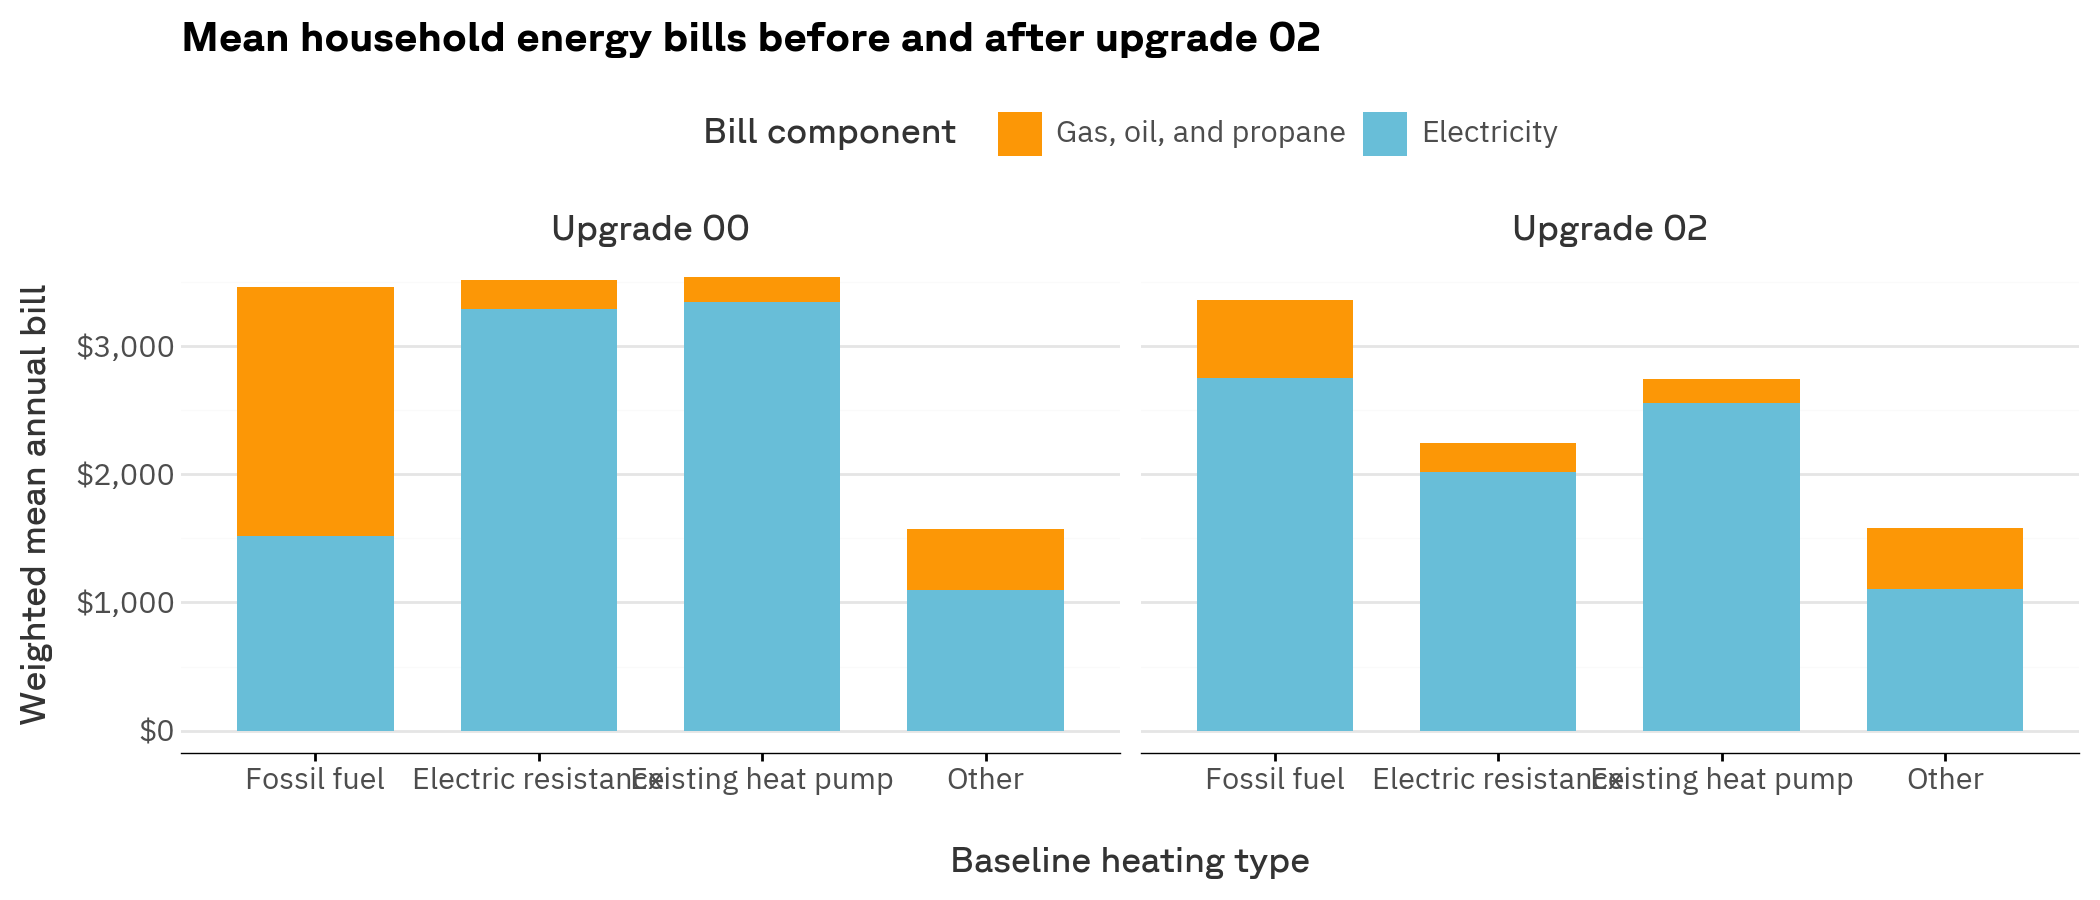

In [7]:
component_rows: list[dict[str, object]] = []
for group in GROUP_ORDER:
    group_df = bill_comparison.filter(pl.col("baseline_heating_type") == group)
    for scenario, suffix in [("Upgrade 00", "before"), ("Upgrade 02", "after")]:
        component_rows.extend(
            [
                {
                    "baseline_heating_type": group,
                    "scenario": scenario,
                    "component": "Electricity",
                    "weighted_mean_bill": weighted_mean(group_df, f"electric_{suffix}"),
                },
                {
                    "baseline_heating_type": group,
                    "scenario": scenario,
                    "component": "Gas, oil, and propane",
                    "weighted_mean_bill": weighted_mean(group_df, f"delivered_fuel_{suffix}"),
                },
            ]
        )

component_plot_data = pl.DataFrame(component_rows).with_columns(
    pl.col("baseline_heating_type").cast(pl.Enum(GROUP_ORDER)),
    pl.col("scenario").cast(pl.Enum(SCENARIO_ORDER)),
    # Plotnine stacks the first level on top, so list delivered fuel first.
    pl.col("component").cast(pl.Enum(["Gas, oil, and propane", "Electricity"])),
)

(
    ggplot(
        component_plot_data,
        aes(x="baseline_heating_type", y="weighted_mean_bill", fill="component"),
    )
    + geom_col(width=0.7)
    + facet_wrap("scenario", ncol=2)
    + scale_fill_manual(
        values={
            "Electricity": SB_COLORS["sky"],
            "Gas, oil, and propane": SB_COLORS["carrot"],
        }
    )
    + scale_y_continuous(labels=lambda xs: [f"${x:,.0f}" for x in xs])
    + labs(
        x="Baseline heating type",
        y="Weighted mean annual bill",
        fill="Bill component",
        title="Mean household energy bills before and after upgrade 02",
    )
    + theme_switchbox()
    + theme(figure_size=(10.5, 4.5), legend_position="top")
)

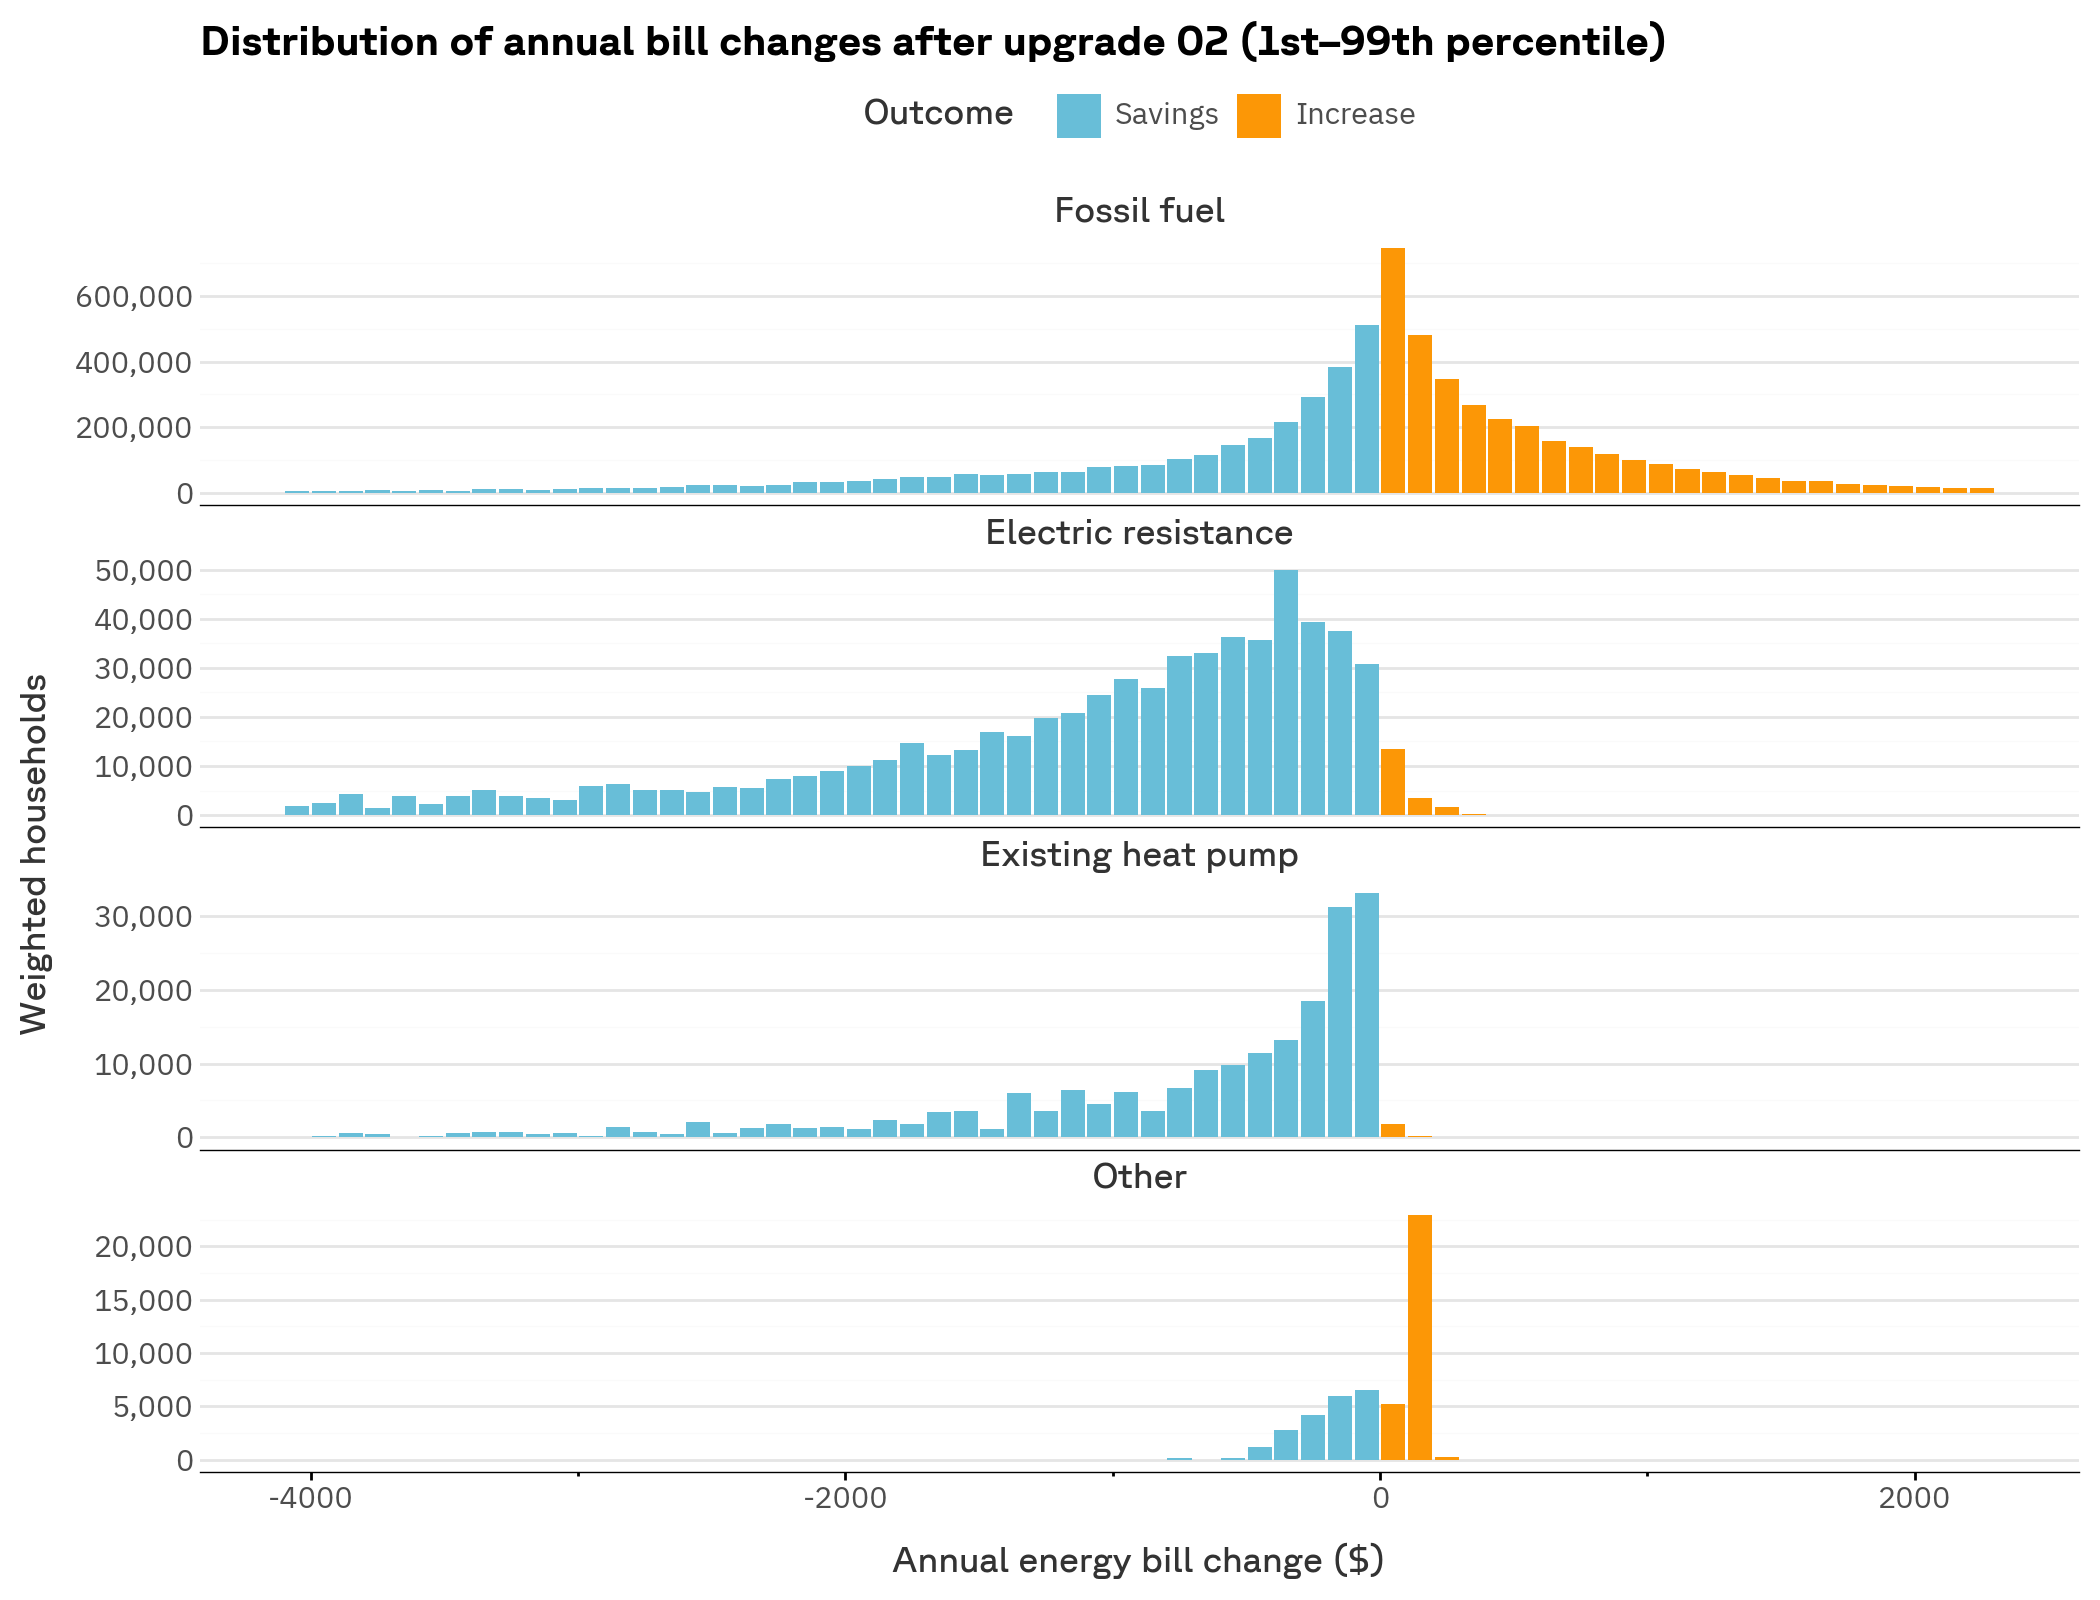

In [8]:
BILL_CHANGE_BIN = 100
bill_change_lo = math.floor(
    weighted_quantile(bill_comparison, "energy_change", 0.01) / BILL_CHANGE_BIN
) * BILL_CHANGE_BIN
bill_change_hi = math.ceil(
    weighted_quantile(bill_comparison, "energy_change", 0.99) / BILL_CHANGE_BIN
) * BILL_CHANGE_BIN

bill_change_hist = (
    bill_comparison.with_columns(
        (
            (pl.col("energy_change") / BILL_CHANGE_BIN).floor() * BILL_CHANGE_BIN
            + BILL_CHANGE_BIN / 2
        ).alias("bin_center"),
        pl.when(pl.col("energy_change") < 0)
        .then(pl.lit("Savings"))
        .otherwise(pl.lit("Increase"))
        .alias("direction"),
    )
    .filter(pl.col("bin_center").is_between(bill_change_lo, bill_change_hi))
    .group_by("baseline_heating_type", "bin_center", "direction")
    .agg(pl.col("weight").sum().alias("weighted_households"))
    .with_columns(
        pl.col("baseline_heating_type").cast(pl.Enum(GROUP_ORDER)),
        pl.col("direction").cast(pl.Enum(["Savings", "Increase"])),
    )
)

(
    ggplot(
        bill_change_hist,
        aes(x="bin_center", y="weighted_households", fill="direction"),
    )
    + geom_col(width=BILL_CHANGE_BIN * 0.9)
    + facet_wrap("baseline_heating_type", ncol=1, scales="free_y")
    + scale_fill_manual(
        values={"Savings": SB_COLORS["sky"], "Increase": SB_COLORS["carrot"]}
    )
    + scale_y_continuous(labels=lambda xs: [f"{x:,.0f}" for x in xs])
    + labs(
        x="Annual energy bill change ($)",
        y="Weighted households",
        fill="Outcome",
        title="Distribution of annual bill changes after upgrade 02 (1st–99th percentile)",
    )
    + theme_switchbox()
    + theme(
        figure_size=(10.5, max(4.5, 2.0 * len(GROUP_ORDER))),
        legend_position="top",
    )
)

## Bill Alignment Test results

BAT equals the annual electric bill minus marginal cost and residual cost allocation. Positive values indicate overpayment relative to cost of service; negative values indicate underpayment. Upgrade 02 rows inherit each building's upgrade 00 heating type.

In [9]:
bat_frames: list[pl.DataFrame] = []
for scenario in SCENARIO_ORDER:
    bat_scenario = bat_by_scenario[scenario].join(
        baseline_groups,
        on=BLDG_ID,
        how="inner",
        validate="1:1",
    ).with_columns(
        pl.lit(scenario).alias("scenario"),
        (pl.col("economic_burden_total") + pl.col("residual_share_total")).alias("cost_of_service_total"),
    )
    bat_frames.append(bat_scenario)

bat_long = pl.concat(bat_frames, how="diagonal_relaxed")

bat_summary_rows: list[dict[str, object]] = []
for scenario in SCENARIO_ORDER:
    for group in GROUP_ORDER:
        group_df = bat_long.filter(
            (pl.col("scenario") == scenario)
            & (pl.col("baseline_heating_type") == group)
        )
        if group_df.is_empty():
            continue
        total_weight = float(group_df["weight"].sum())
        overpay_weight = float(
            group_df.filter(pl.col("BAT_percustomer_total") > 0)["weight"].sum()
        )
        bat_summary_rows.append(
            {
                "scenario": scenario,
                "baseline heating type": group,
                "weighted mean bill": weighted_mean(group_df, "annual_bill_total"),
                "weighted mean cost of service": weighted_mean(group_df, "cost_of_service_total"),
                "weighted mean BAT": weighted_mean(group_df, "BAT_percustomer_total"),
                "weighted median BAT": weighted_quantile(group_df, "BAT_percustomer_total", 0.5),
                "households overpaying": overpay_weight / total_weight,
            }
        )

bat_summary = pl.DataFrame(bat_summary_rows)
display(bat_summary)

scenario,baseline heating type,weighted mean bill,weighted mean cost of service,weighted mean BAT,weighted median BAT,households overpaying
str,str,f64,f64,f64,f64,f64
"""Upgrade 00""","""Fossil fuel""",1515.319009,1647.096553,-131.777544,-208.776876,0.306486
"""Upgrade 00""","""Electric resistance""",3289.7773,2288.785412,1000.991888,502.5949,0.748892
"""Upgrade 00""","""Existing heat pump""",3343.8258,2370.142712,973.683087,461.537772,0.694386
"""Upgrade 00""","""Other""",1096.794794,1330.485112,-233.690318,-257.072923,0.128254
"""Upgrade 02""","""Fossil fuel""",2748.230564,968811.602916,-966063.372352,-649778.388567,0.0
"""Upgrade 02""","""Electric resistance""",2021.011555,932681.172989,-930660.161434,-649956.358602,0.0
"""Upgrade 02""","""Existing heat pump""",2552.52301,1.1092e6,-1.1066e6,-650312.923435,0.0
"""Upgrade 02""","""Other""",1102.965534,363950.734142,-362847.768609,-324834.913154,0.0


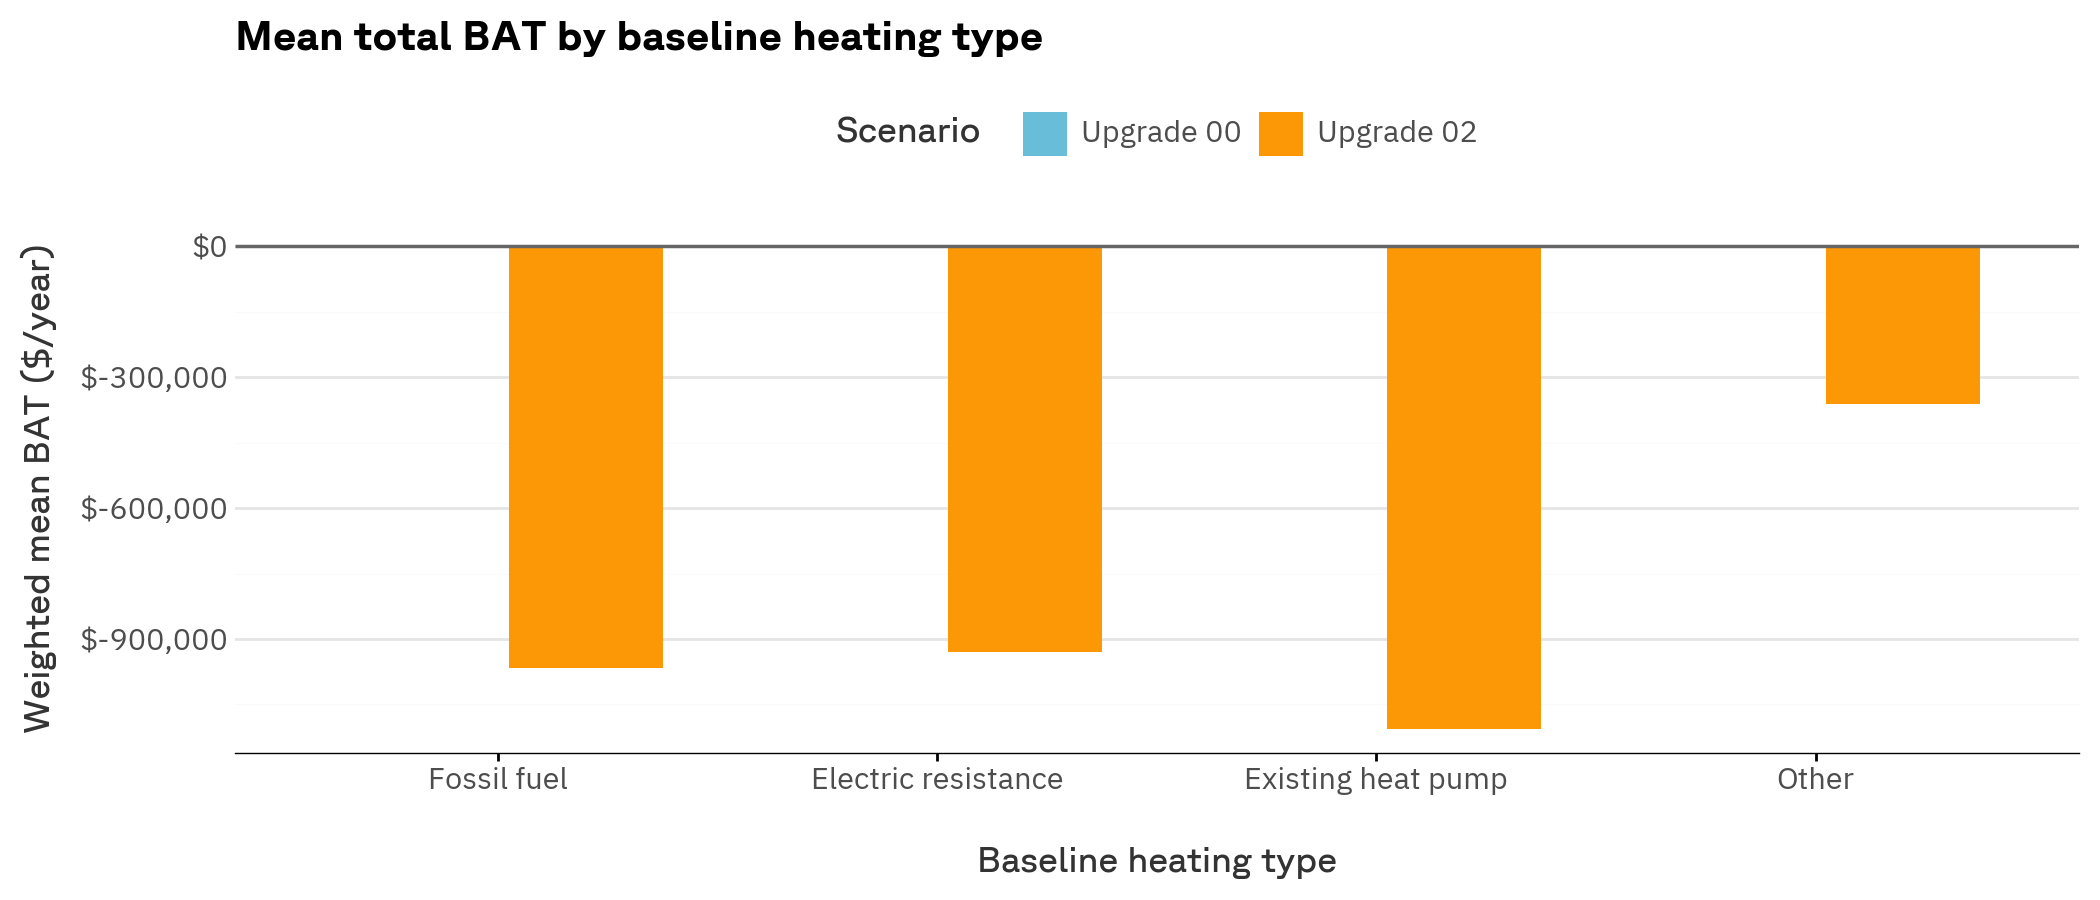

In [10]:
bat_plot_data = bat_summary.rename(
    {
        "baseline heating type": "baseline_heating_type",
        "weighted mean BAT": "mean_bat",
    }
).with_columns(
    pl.col("baseline_heating_type").cast(pl.Enum(GROUP_ORDER)),
    pl.col("scenario").cast(pl.Enum(SCENARIO_ORDER)),
)

(
    ggplot(
        bat_plot_data,
        aes(x="baseline_heating_type", y="mean_bat", fill="scenario"),
    )
    + geom_col(position=position_dodge(width=0.8), width=0.7)
    + geom_hline(yintercept=0, color="#666666", size=0.7)
    + scale_fill_manual(
        values={
            "Upgrade 00": SB_COLORS["sky"],
            "Upgrade 02": SB_COLORS["carrot"],
        }
    )
    + scale_y_continuous(labels=lambda xs: [f"${x:,.0f}" for x in xs])
    + labs(
        x="Baseline heating type",
        y="Weighted mean BAT ($/year)",
        fill="Scenario",
        title="Mean total BAT by baseline heating type",
    )
    + theme_switchbox()
    + theme(figure_size=(10.5, 4.5), legend_position="top")
)

## Monthly bill pattern

Monthly weighted means show when the heat-pump upgrade raises electric bills and when reduced fossil-fuel use offsets those increases.

scenario,month,weighted_mean_energy_bill
enum,enum,f64
"""Upgrade 00""","""Jan""",520.340206
"""Upgrade 00""","""Feb""",371.189947
"""Upgrade 00""","""Mar""",393.665096
"""Upgrade 00""","""Apr""",295.411291
"""Upgrade 00""","""May""",177.300088
…,…,…
"""Upgrade 02""","""Aug""",205.836428
"""Upgrade 02""","""Sep""",170.945828
"""Upgrade 02""","""Oct""",199.186401


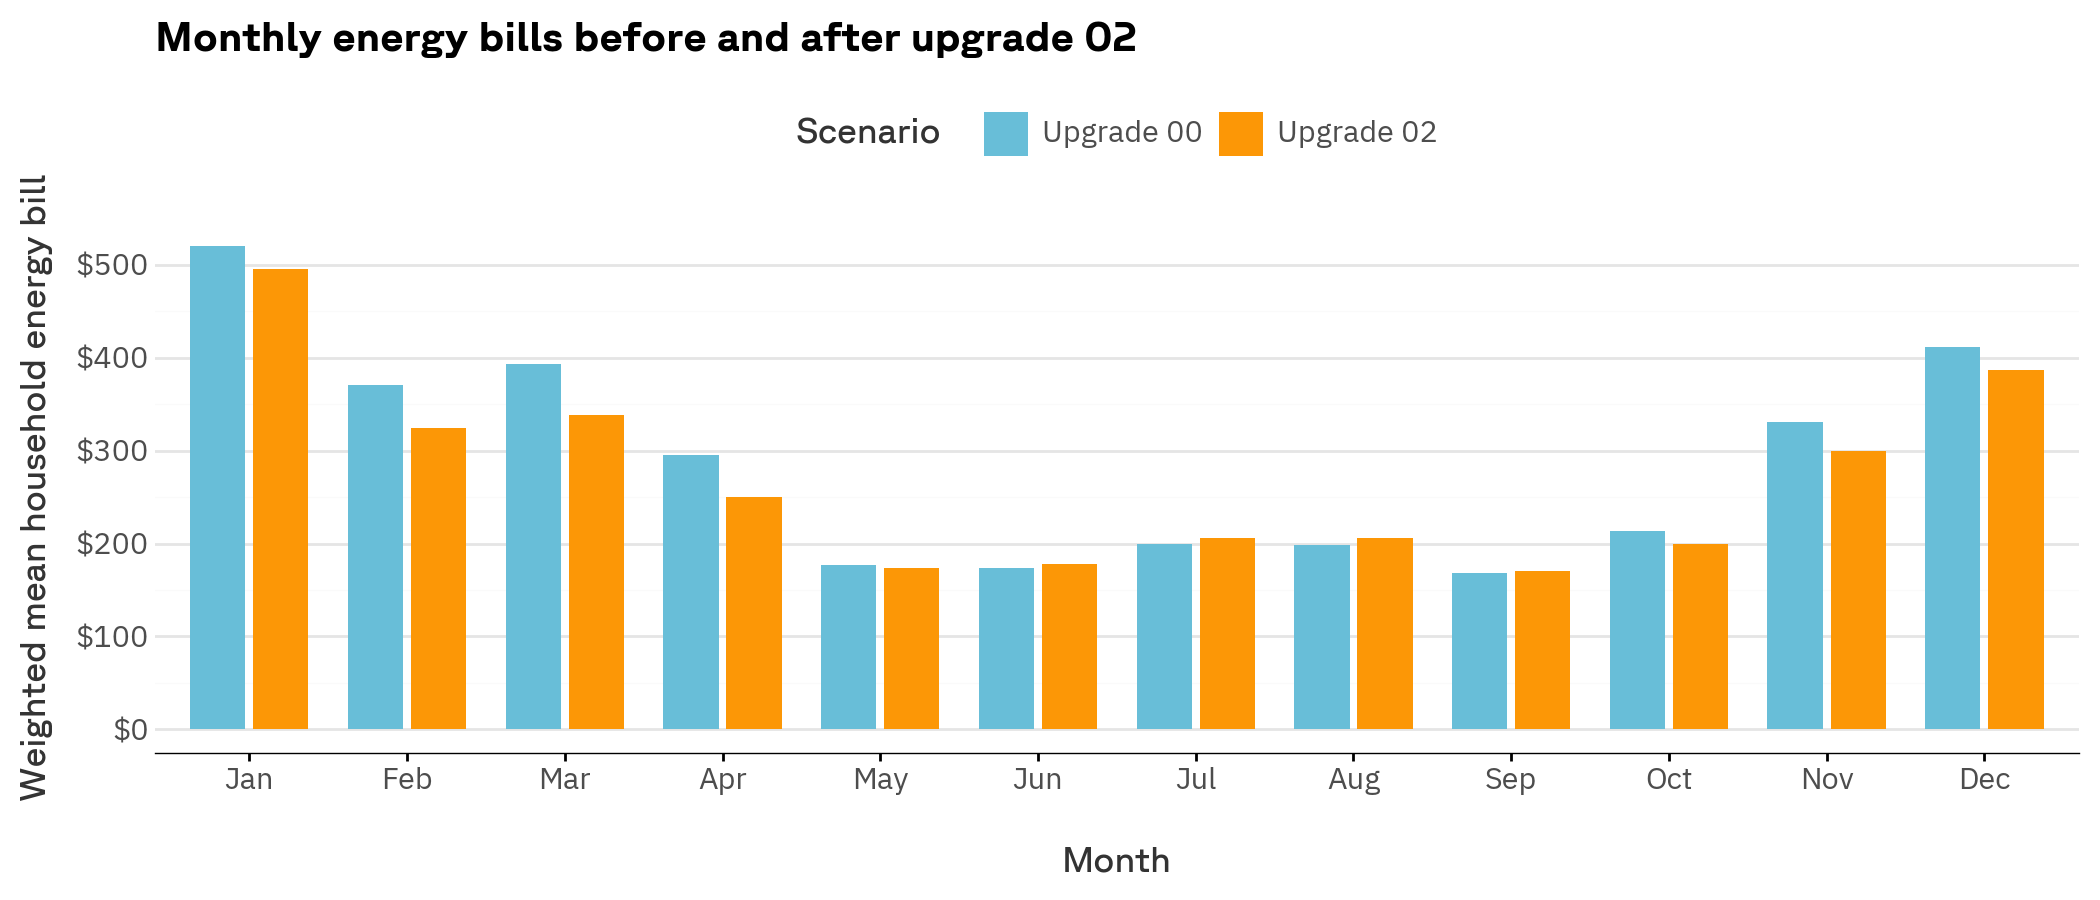

In [11]:
monthly_rows: list[dict[str, object]] = []
for scenario in SCENARIO_ORDER:
    monthly = bills_by_scenario[scenario].filter(pl.col("month").is_in(MONTH_ORDER))
    for month in MONTH_ORDER:
        month_df = monthly.filter(pl.col("month") == month)
        monthly_rows.append(
            {
                "scenario": scenario,
                "month": month,
                "weighted_mean_energy_bill": weighted_mean(month_df, "energy_total_bill"),
            }
        )

monthly_summary = pl.DataFrame(monthly_rows).with_columns(
    pl.col("scenario").cast(pl.Enum(SCENARIO_ORDER)),
    pl.col("month").cast(pl.Enum(MONTH_ORDER)),
)
display(monthly_summary)

(
    ggplot(
        monthly_summary,
        aes(x="month", y="weighted_mean_energy_bill", fill="scenario"),
    )
    + geom_col(position=position_dodge(width=0.8), width=0.7)
    + scale_fill_manual(
        values={
            "Upgrade 00": SB_COLORS["sky"],
            "Upgrade 02": SB_COLORS["carrot"],
        }
    )
    + scale_x_discrete(limits=MONTH_ORDER)
    + scale_y_continuous(labels=lambda xs: [f"${x:,.0f}" for x in xs])
    + labs(
        x="Month",
        y="Weighted mean household energy bill",
        fill="Scenario",
        title="Monthly energy bills before and after upgrade 02",
    )
    + theme_switchbox()
    + theme(figure_size=(10.5, 4.5), legend_position="top")
)

## Utility-level summary

For multi-utility states, this table quickly identifies territories with unusual bill changes or bill alignment. It remains valid for single-utility states such as Rhode Island.

In [12]:
utility_rows: list[dict[str, object]] = []
for utility in sorted(bill_comparison[UTILITY_COL].unique().to_list()):
    utility_bills = bill_comparison.filter(pl.col(UTILITY_COL) == utility)
    for scenario in SCENARIO_ORDER:
        utility_bat = bat_long.filter(
            (pl.col(UTILITY_COL) == utility) & (pl.col("scenario") == scenario)
        )
        utility_rows.append(
            {
                "utility": utility,
                "scenario": scenario,
                "sample buildings": utility_bat.height,
                "weighted households": round(float(utility_bat["weight"].sum())),
                "weighted mean total BAT": weighted_mean(utility_bat, "BAT_percustomer_total"),
                "weighted median total BAT": weighted_quantile(utility_bat, "BAT_percustomer_total", 0.5),
                "weighted mean bill change": (
                    0.0 if scenario == "Upgrade 00" else weighted_mean(utility_bills, "energy_change")
                ),
            }
        )

utility_summary = pl.DataFrame(utility_rows)
display(utility_summary)

utility,scenario,sample buildings,weighted households,weighted mean total BAT,weighted median total BAT,weighted mean bill change
str,str,i64,i64,f64,f64,f64
"""cenhud""","""Upgrade 00""",1182,270859,3.1255e-12,-227.248726,0.0
"""cenhud""","""Upgrade 02""",1182,270859,-3.6886e6,-3.6887e6,-733.581717
"""coned""","""Upgrade 00""",15435,3064038,-2.1219e-11,-178.654389,0.0
"""coned""","""Upgrade 02""",15435,3064038,-324178.202264,-324436.69905,-148.40005
"""nimo""","""Upgrade 00""",6791,1532294,-2.4499e-11,-150.003962,0.0
…,…,…,…,…,…,…
"""or""","""Upgrade 02""",829,211011,-4.7359e6,-4.7360e6,-312.592456
"""psegli""","""Upgrade 00""",4427,1029955,-1.3687e-11,-116.113917,0.0
"""psegli""","""Upgrade 02""",4427,1029955,-967458.790291,-967503.544667,-577.154952


## Interpretation checklist

Before using these results in a report or policy analysis:

1. Confirm that every structural assertion passes.
2. Check that weighted household totals are stable across scenarios and plausible for the modeled service territories.
3. Investigate heating groups or utilities with extreme bill changes before summarizing statewide results.
4. Confirm that BAT signs and magnitudes are consistent with the intended residual allocation method.
5. Treat the 1st–99th percentile histogram as a visualization choice only; inspect excluded tails separately when diagnosing outliers.
6. Change `STATE` and `BATCH`, restart the kernel, and run all cells to review another batch.